
# DL Mid term exam

**Name:** Subrata Saha

**Course Email:**  subratabaec@gmail.com


**Date:** 7th March, 2026

## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

Draw a Neural Network

Draw a neural network with:

3 input features

3 hidden layers (at least 2 neurons each)

1 output neuron

a) Label all weights and biases. <br>
b) Write the forward equations layer by layer. <br>
c) If output uses Sigmoid, write the final prediction equation. <br>

Please note : Don't forget to attach a screen short of your neural network.

## Write Answer 01:


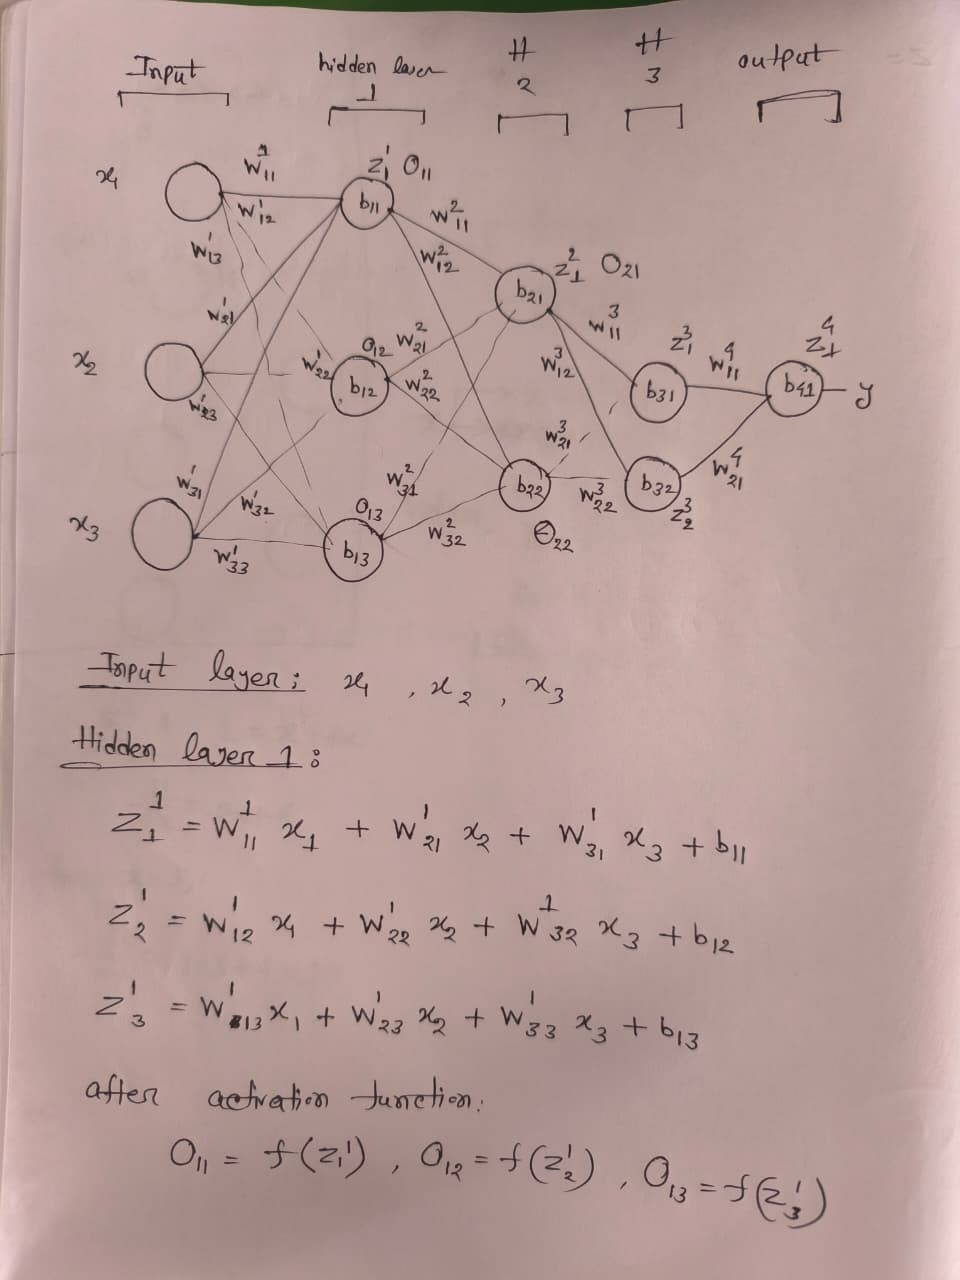



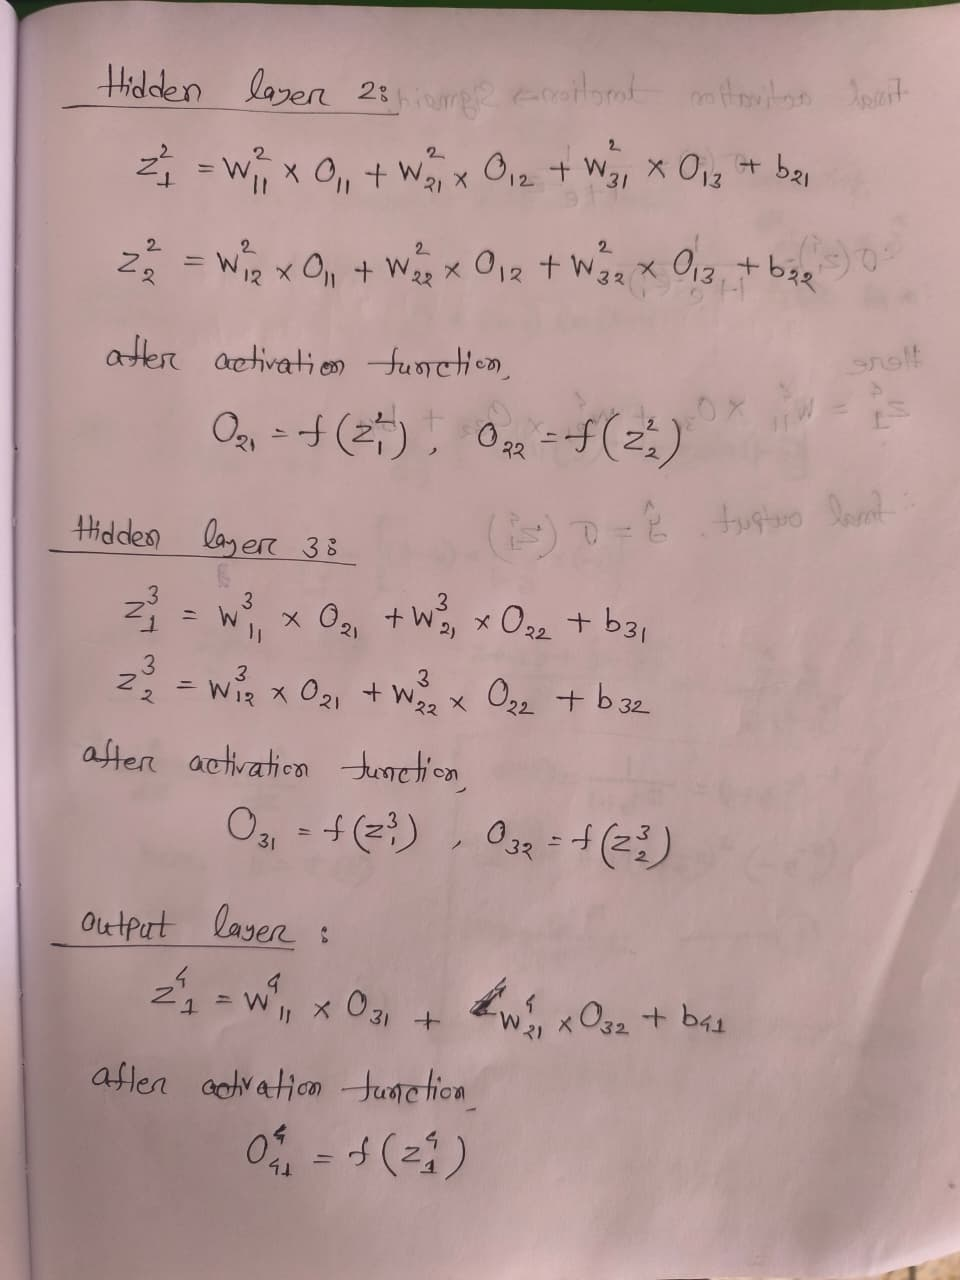

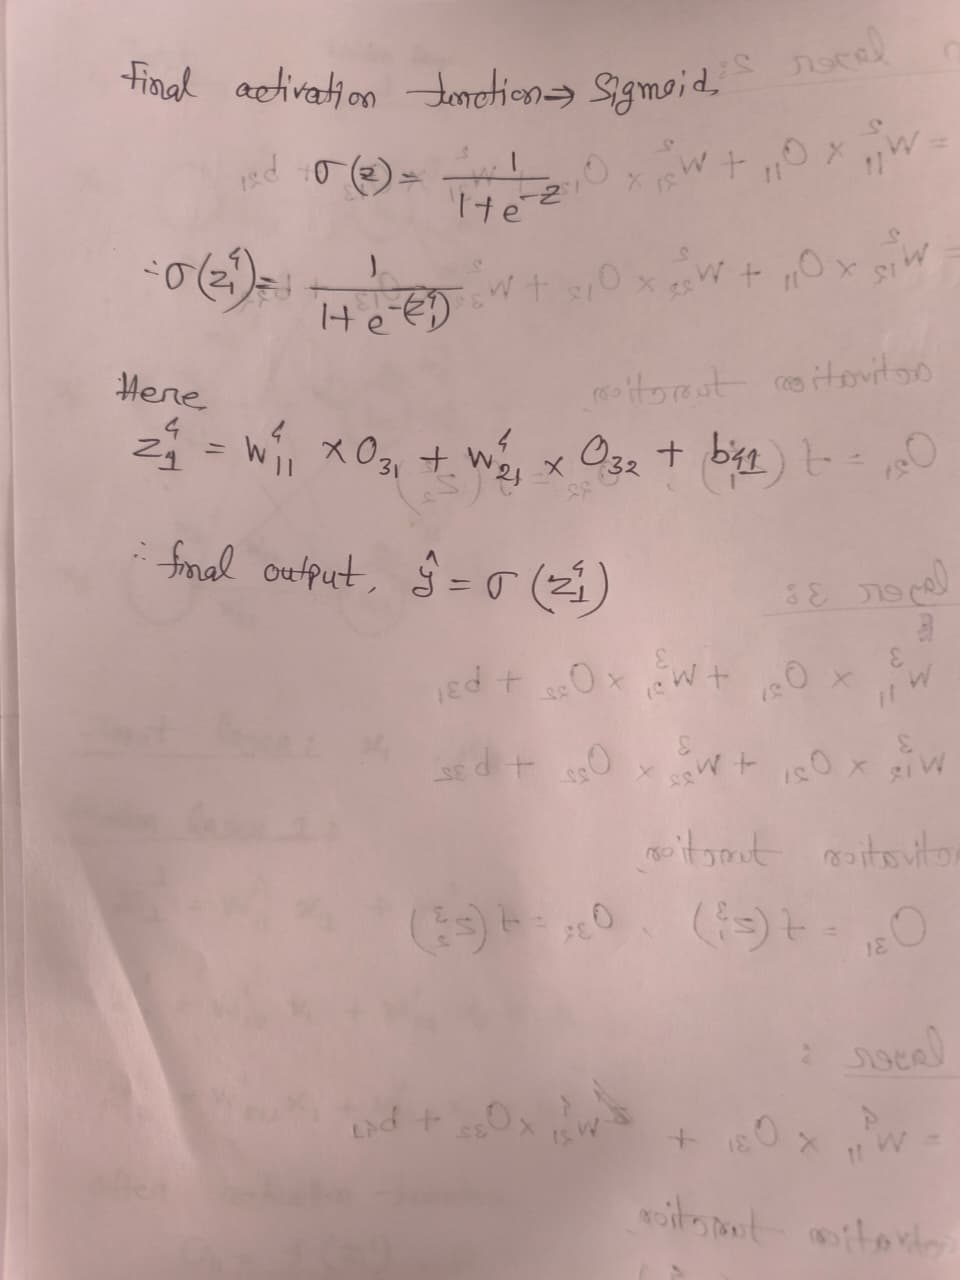

# Question 02: [ Marks 20 ]

Manual Gradient Calculation

Given:

z = w*x + b <br>
y_pred = sigmoid(z) <br>
L = −[ y log(y_pred) + (1−y) log(1−y_pred) ] <br>

a) Write dL/dy_pred <br>
b) Write dy_pred/dz <br>
c) Show that dL/dz = y_pred − y <br>

## Write Answer 02:


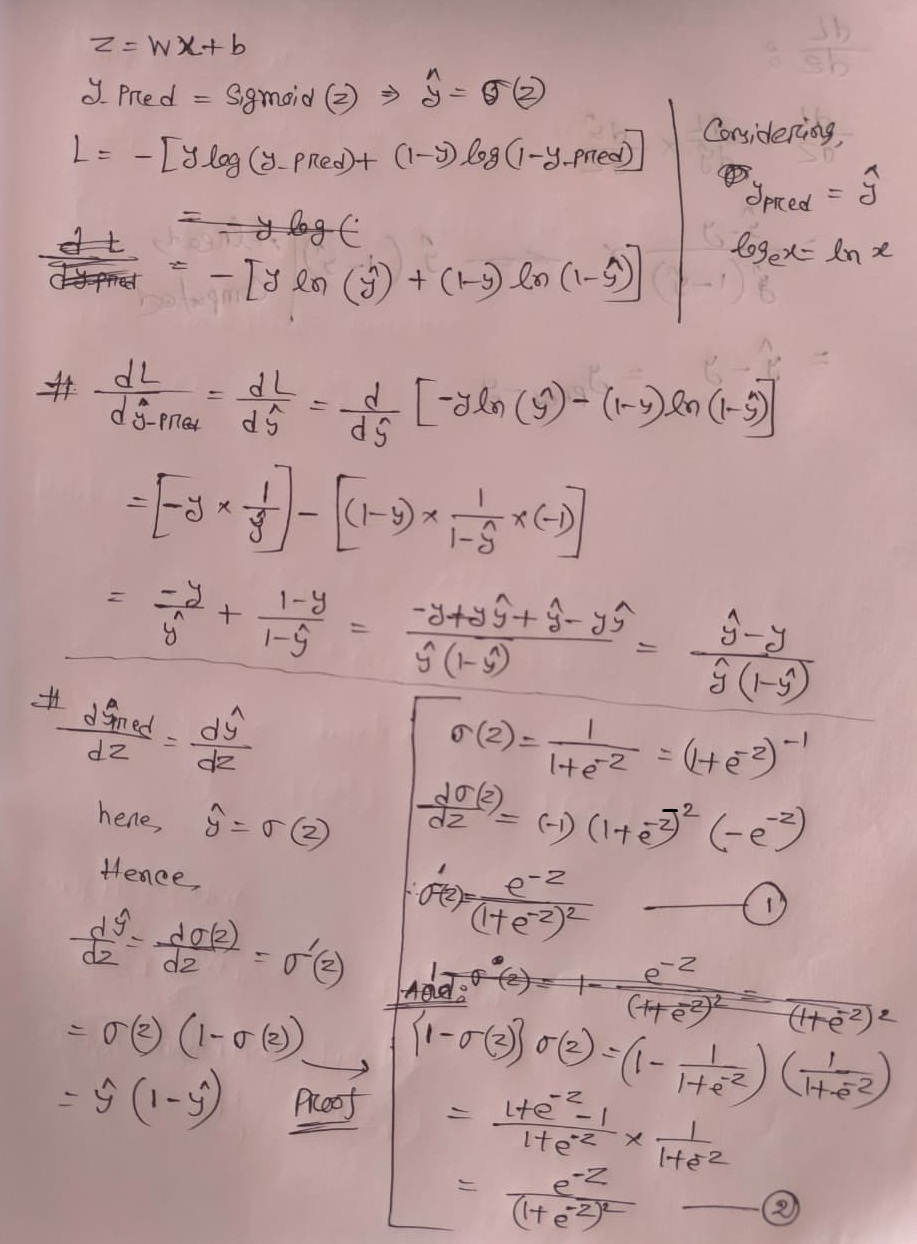

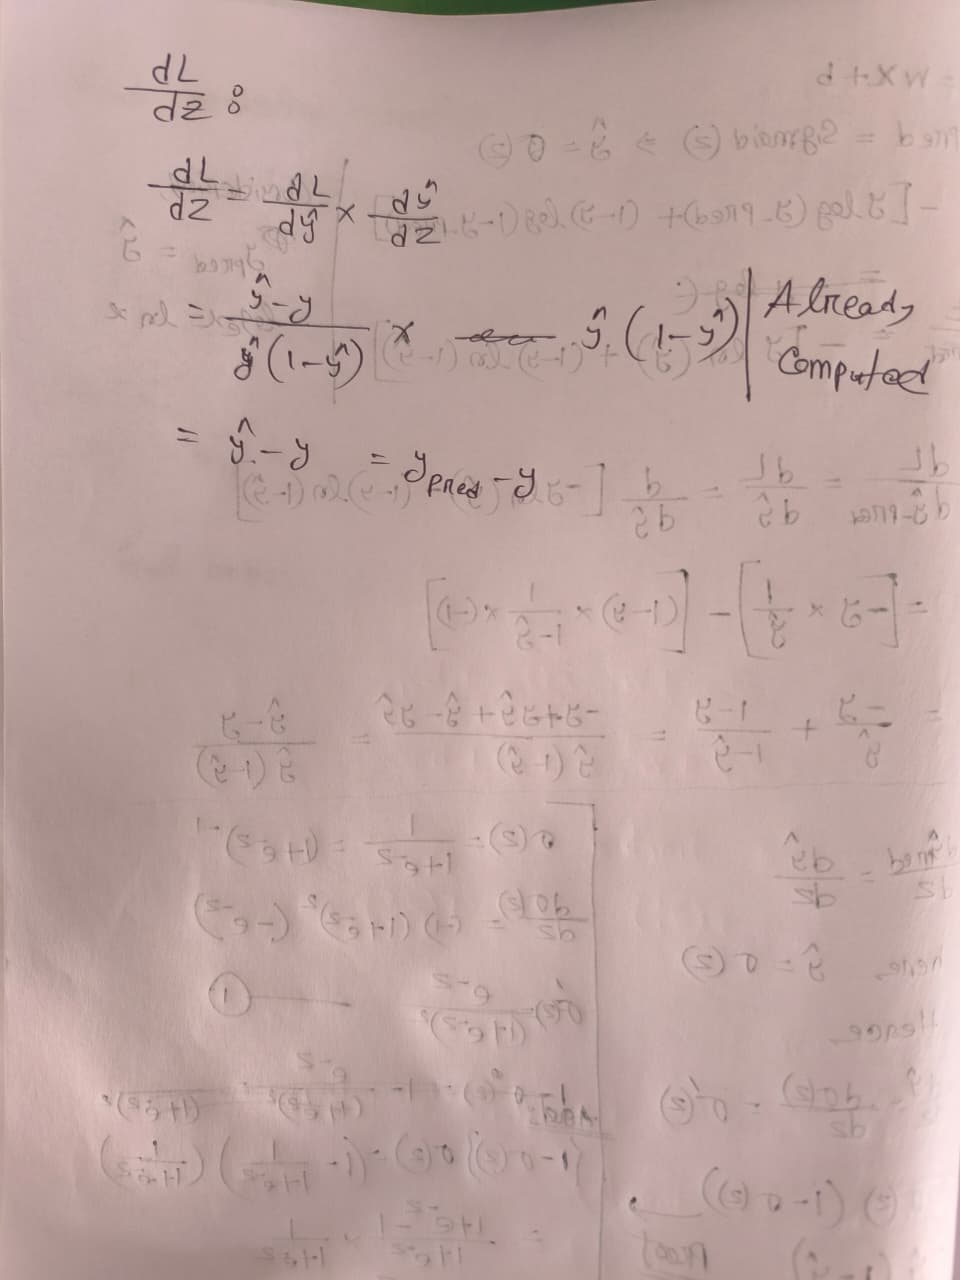

# Question 03: [ Marks 15 ]

x = 3
y1 = x^2
y2 = 4*x
L = y1 + y2

a) Draw the computation graph. <br>
b) Compute dL/dx manually. <br>
c) Explain how would you do it using Autograd <br>

## Write Answer 03:



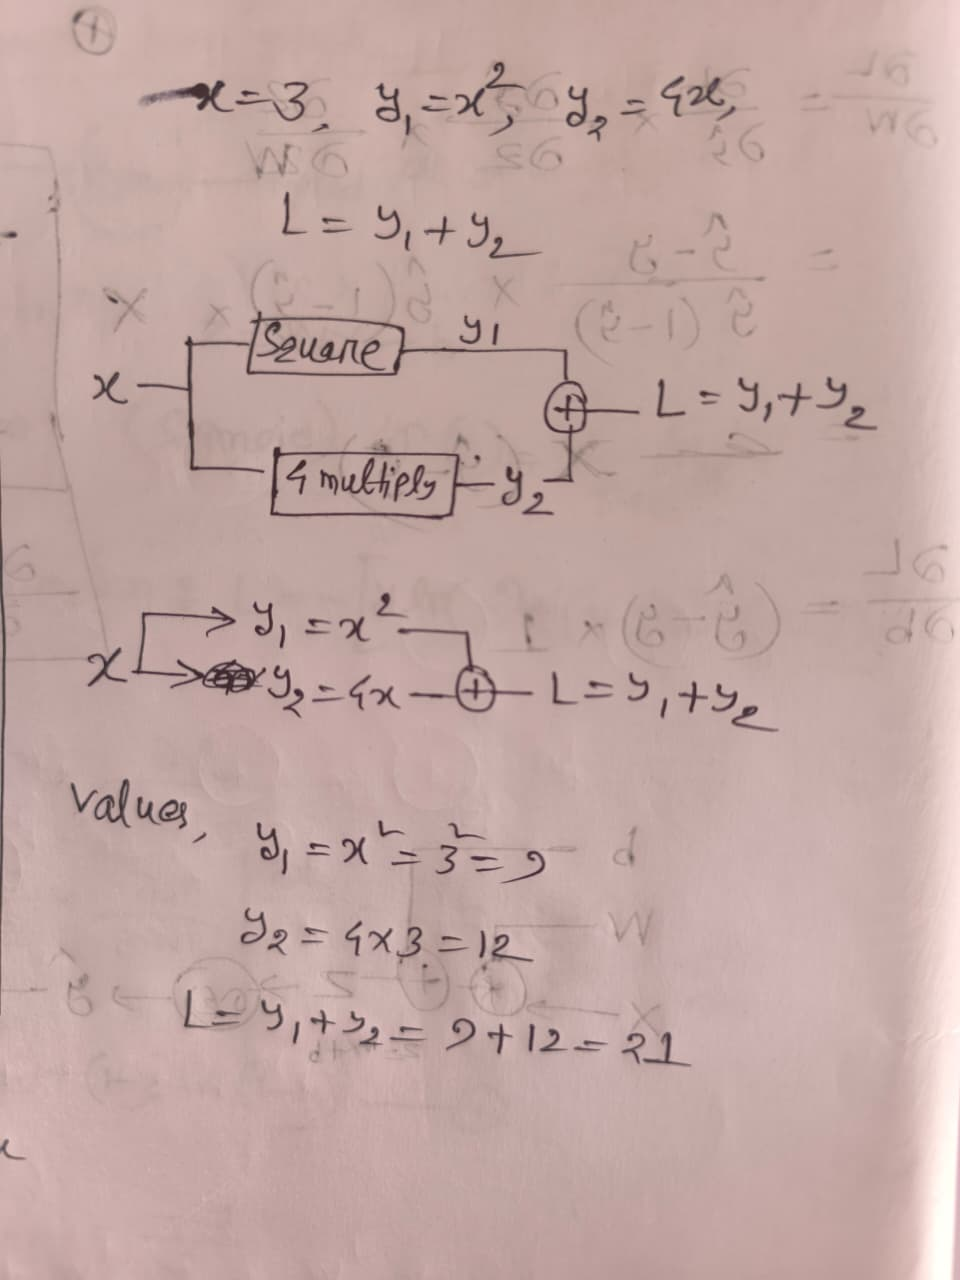

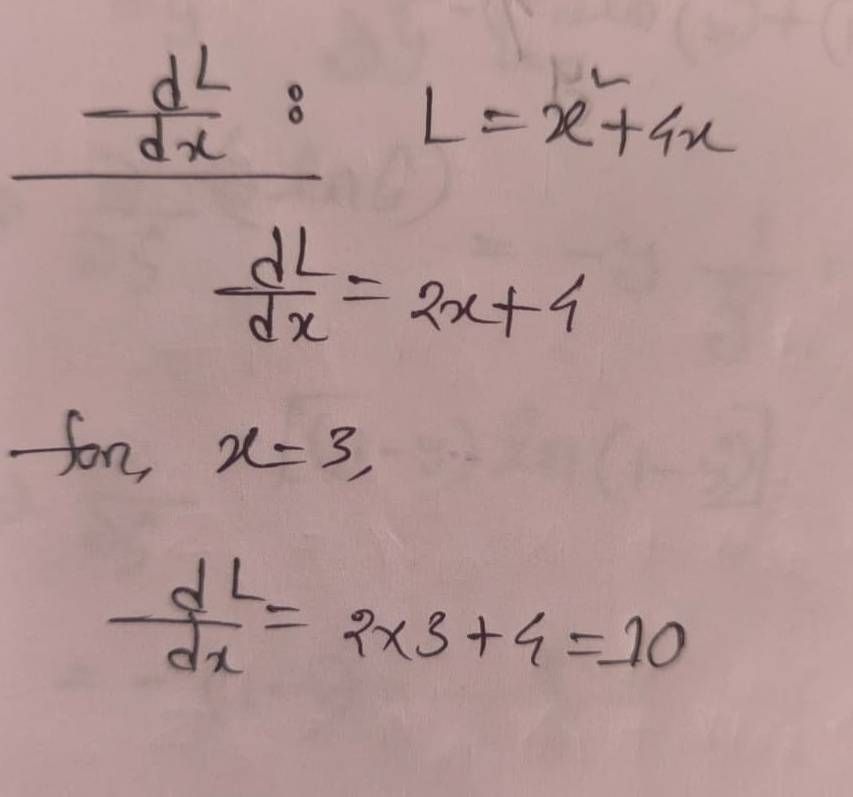

Forward pass:

Autograd first tracks all operations during the forward pass and builds a computation graph showing how L depends on x.

Following operastions are performed in this step.
y1 = x² , y2 = 4x, L = y1 + y2

Backward pass:

When backpropagation started, Autograd moves backward through this graph and automatically applies the chain rule to compute the derivative.

Finally, the gradient dL/dx is automatically calculated and stored.

In [25]:
import torch
x=torch.tensor(3.0,requires_grad=True) # tracking enabled

y=x**2
z=4*x
L=y+z

L.backward()

print(L) # output after forward pass
print(x.grad) # derivative in the backward pass, for weight updation

tensor(21., grad_fn=<AddBackward0>)
tensor(10.)


# Question 04: [ Marks 15 ]

Create a scalar tensor x = 3.0 with gradient tracking enabled. <br>
Compute y = x² + 4x. <br>
Perform backpropagation. <br>
Print the gradient of x. <br>

Write the full PyTorch code yourself. <br>

## Write Answer 04:

In [26]:
x=torch.tensor(3.0,requires_grad=True) # tracking enabled

y=x**2 + 4*x # computation

y.backward()  # backpropagation

print(y) # output after forward pass
print(x.grad) # derivative in the backward pass, this is for weight updation

tensor(21., grad_fn=<AddBackward0>)
tensor(10.)


# Question 05: [ Marks 10 ]

Create two tensors:
w = 2.0 (requires_grad=True) <br>
b = 1.0 (requires_grad=True) <br>

Let input x = 3.0. <br>
Compute z = w*x + b. <br>
Use Sigmoid to get y_pred.
 <br>

Define Binary Cross Entropy manually (without built-in loss). <br>
Compute gradients using backward(). <br>
Print gradients of w and b. <br>

Write full code.

## Write Answer 05:

In [27]:
# weights
w=torch.tensor(2.0,requires_grad=True)
b=torch.tensor(1.0,requires_grad=True)

# inputs
x=torch.tensor(3.0)
y=torch.tensor(1.0) # considering y=1

# linear output
z=w*x+b

# prediction using activation function
y_pred=torch.sigmoid(z)

# loss function - BCE
L=-(y*torch.log(y_pred)+(1-y)*torch.log(1-y_pred))

# backwardpass
L.backward()


print(z)
print(y_pred)
print(L)

# print gradients
print(w.grad) # dL_dw
print(b.grad) # dL_db

tensor(7., grad_fn=<AddBackward0>)
tensor(0.9991, grad_fn=<SigmoidBackward0>)
tensor(0.0009, grad_fn=<NegBackward0>)
tensor(-0.0027)
tensor(-0.0009)


# Question 06: [ Marks 10 ]

Create a tensor x = 2.0 (requires_grad=True). <br>
Compute:

y1 = x² <br>
y2 = 3x <br>
L = y1 + y2 <br>

Call backward(). <br>
Print x.grad. <br>

Write full PyTorch code.

## Write Answer 06:

In [28]:
x=torch.tensor(2.0,requires_grad=True)

y1=x**2
y2=3*x
L=y1+y2

L.backward()

print(L)
print(x.grad) # dL_dx

tensor(10., grad_fn=<AddBackward0>)
tensor(7.)


# Question 07: [ Marks 20 ]


Create tensor w = 2.0 (requires_grad=True). <br>

Compute two different losses sequentially and call backward() twice. <br>
Print w.grad. <br>

Do not clear gradients. <br>
Explain what you observe. <br>

Write full code.


## Write Answer 07:



In [29]:
w=torch.tensor(2.0,requires_grad=True)

# considering two random loss functions
L1=w**2
L2=w*3

# derivative of first loss
L1.backward()
print(w.grad)

# derivative of second loss
L2.backward()
print(w.grad)

tensor(4.)
tensor(7.)


#### observation:
In this problem, two different losses are computed sequentially for the same tensor w.

PyTorch accumulates gradients by default, so after the first "backwad()", "w.grad" contains the gradient of the first loss (dL1_dw). The stored value does not cleared automatically. When the second "backward()" is called, its gradient is added to the existing gradient. like this,

dL2_dw = dL1_dw + dL2_dw

That’s why the final "w.grad" is the sum of the gradients from both losses.

to solve this problem, "w.grad" needs to be cleared before calling the second "backward()".

### Finish